# 03. Model Explainability (XAI) - EigenCAM & Feature Maps

In this notebook, we evaluate the **Trustworthiness** and **Transparency** (FAT principles) 
of our YOLOv10 "Black-Box" core by visualizing exactly where the neural network is looking. 

We extract internal layer activations (Feature Maps) and use **Principal Component Analysis (PCA)** 
to compute the **EigenCAM** (Eigen Class Activation Map) heatmaps.

In [1]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

PROJECT_ROOT = Path("..").resolve()
MODEL_PATH = PROJECT_ROOT / "models" / "weights" / "fruit_disease_v1" / "weights" / "best.pt"

print("Dependencies Loaded. Preparing XAI Environment...")

Dependencies Loaded. Preparing XAI Environment...


In [2]:
# Load the fine-tuned YOLOv10 object detector
model = YOLO(str(MODEL_PATH))
pt_model = model.model  # Unpack internal PyTorch Neural Network

In [3]:
def compute_eigencam(image_path, target_layer_idx=10):
    """
    Extracts YOLOv10 internal spatial features and converts them to a visual Heatmap using PCA.
    """
    # 1. Register a Forward Hook to intercept the Feature Maps
    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach())
        
    # Target specific backbone/neck layer (10 is typically a pooling/C2f layer with rich spatial features)
    target_layer = pt_model.model[target_layer_idx]
    handle = target_layer.register_forward_hook(hook_fn)
    
    # 2. Image Preprocessing (Formatting image specifically for PyTorch)
    img_path_str = str(image_path)
    img = cv2.imread(img_path_str)
    if img is None:
        raise ValueError(f"Could not load {img_path_str}")
        
    img_resized = cv2.resize(img, (640, 640))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    img_tensor = torch.from_numpy(img_rgb).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    img_tensor = img_tensor.to(model.device)
    
    # 3. Model Forward Pass (Extraction)
    with torch.no_grad():
        pt_model(img_tensor)
        
    handle.remove()
    
    # 4. Apply Principal Component Analysis (Eigen-CAM Algorithm)
    feature_map = activations[0].cpu().numpy()[0] # Shape: [Channels, Height, Width]
    C, H, W = feature_map.shape
    
    # Reshape and mean centering
    reshaped = feature_map.reshape(C, H * W)
    reshaped = reshaped - reshaped.mean(axis=1, keepdims=True)
    
    # SVD mathematically extracts the most prominent "features" the AI found
    U, S, Vt = np.linalg.svd(reshaped, full_matrices=False)
    
    # First principal component contains the central subject focus
    first_pc = Vt[0, :].reshape(H, W)
    
    # 5. Normalize and Format to Image Mask
    first_pc = first_pc - np.min(first_pc)
    first_pc = first_pc / (np.max(first_pc) + 1e-7)
    
    heatmap = cv2.resize(first_pc, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_colored = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    # 6. Apply Heatmap over Original Image
    superimposed = heatmap_colored * 0.4 + cv2.cvtColor(img, cv2.COLOR_BGR2RGB) * 0.6
    superimposed = np.clip(superimposed, 0, 255).astype(np.uint8)
    
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB), superimposed, heatmap_colored

### EigenCAM Execution
Choose a target image and observe exactly which areas “activate” the object detector!

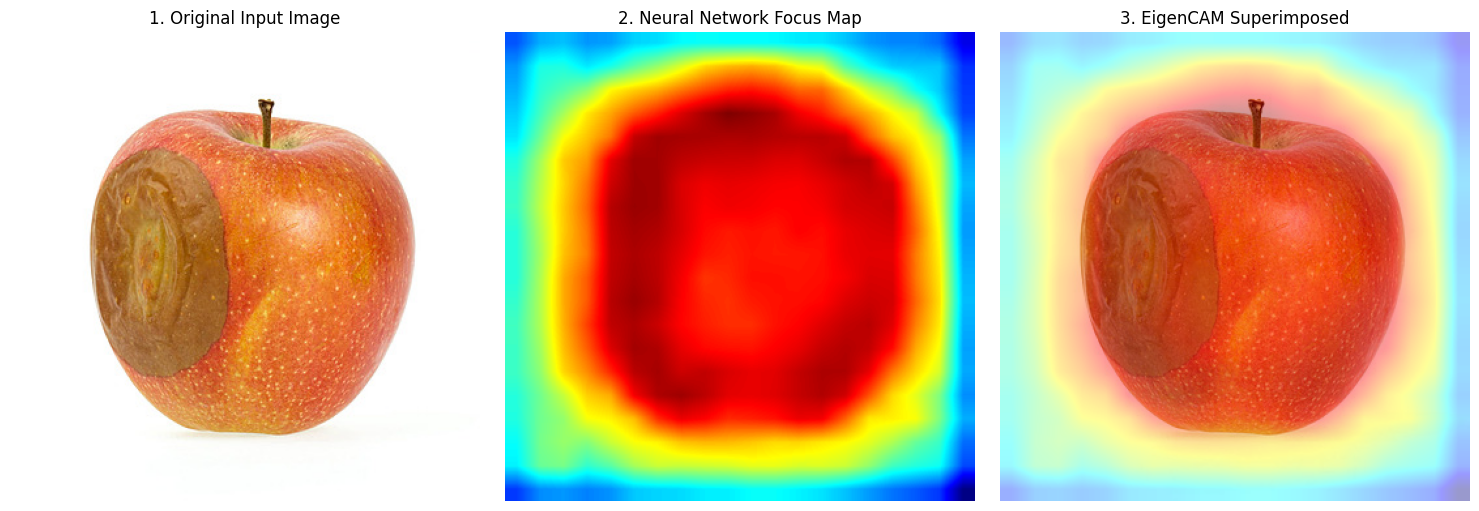

In [4]:
TEST_IMAGE = PROJECT_ROOT / "data" / "test_images" / "tao_hong_1.jpg"

try:
    orig_img, heat_layer, pure_heatmap = compute_eigencam(TEST_IMAGE, target_layer_idx=10)
    
    # Plotting
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(orig_img)
    plt.title("1. Original Input Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(pure_heatmap)
    plt.title("2. Neural Network Focus Map")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(heat_layer)
    plt.title("3. EigenCAM Superimposed")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Processing failed: {e}")